In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 — Setup

In [ ]:
c!pip install -q pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob, zipfile, shutil
from dataclasses import dataclass


In [ ]:
# --- Get the dataset into Colab -----------------------------------------------

import os
import shutil
import zipfile
from google.colab import files

ZIP_PATH = "/content/drive/MyDrive/VO2 estimation/Dataset.zip"
DATA_ROOT = "/content/dataset_extracted"

# If ZIP is not found in Google Drive, upload it manually
if not os.path.exists(ZIP_PATH):
    print("Please choose your Dataset.zip file to upload:")
    uploaded = files.upload()
    ZIP_PATH = list(uploaded.keys())[0]

# Remove previous extraction if it exists
if os.path.exists(DATA_ROOT):
    shutil.rmtree(DATA_ROOT)

os.makedirs(DATA_ROOT, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATA_ROOT)

print("Extracted to:", DATA_ROOT)

# Show extracted files/folders
for root, dirs, file_names in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for filename in file_names[:10]:
        print(f"{indent}  {filename}")

Extracted to: /content/dataset_extracted
dataset_extracted/
  Sarabeshwar L/
    20250828_112528/
      summary.csv
      corrected_hr_avg.csv
      hr.csv
      acc_rms_avg.csv
      hr_quality.csv
    20250908_002251/
      summary.csv
      index.csv
      corrected_hr_avg.csv
      hr.csv
      acc_rms_avg.csv
      hr_quality.csv
      ecg/
        4.csv
        0.csv
        2.csv
        3.csv
        1.csv
    20250819_114029/
      summary.csv
      index.csv
      corrected_hr_avg.csv
      hr.csv
      acc_rms_avg.csv
      hr_quality.csv
      ecg/
        0.csv
    20250819_022720/
      summary.csv
      index.csv
      corrected_hr_avg.csv
      hr.csv
      acc_rms_avg.csv
      hr_quality.csv
      ecg/
        4.csv
        0.csv
        2.csv
        3.csv
        1.csv
    20250915_004000/
      summary.csv
      index.csv
      corrected_hr_avg.csv
      hr.csv
      acc_rms_avg.csv
      hr_quality.csv
      ecg/
        4.csv
        0.csv
        2.csv
        3

In [ ]:
# Auto-detect session folders: any directory that directly contains
# corrected_hr_avg.csv and acc_rms_avg.csv is treated as one "session".
def find_sessions(root):
    sessions = []
    for dirpath, dirnames, filenames in os.walk(root):
        if "corrected_hr_avg.csv" in filenames and "acc_rms_avg.csv" in filenames:
            sessions.append(dirpath)
    return sorted(sessions)

SESSION_DIRS = find_sessions(DATA_ROOT)
print(f"Found {len(SESSION_DIRS)} sessions")
for s in SESSION_DIRS[:5]:
    print(" ", s)


Found 57 sessions
  /content/dataset_extracted/Sarabeshwar L/20250815_230720
  /content/dataset_extracted/Sarabeshwar L/20250815_234614
  /content/dataset_extracted/Sarabeshwar L/20250818_002203
  /content/dataset_extracted/Sarabeshwar L/20250818_002908
  /content/dataset_extracted/Sarabeshwar L/20250818_111219


## 2 — The reliability-gating algorithm

Firstbeat's PDF names the periods it rejects before building the HR–speed
relationship:

| Firstbeat rejects | Signal we have | How we detect it here |
|---|---|---|
| Soft ground | *(no terrain sensor)* | not detectable — **not implemented**, noted as a limitation |
| Steep downhill | *(no GPS/altitude)* | not detectable — **not implemented**, noted as a limitation |
| Stopping / traffic light | HR stays elevated while RMS drops to ~0 | **`bad_stop`**: RMS below threshold *while* HR is still elevated vs. its own recent minimum |
| Cardiovascular drift (long exercise) | HR rises while load stays flat | **`bad_drift`**: rolling-window linear slope of HR > threshold while RMS slope ≈ 0 |
| Other unreliable periods | sensor artifacts, dropouts, poor contact | **`bad_missing`**, **`bad_quality`**, **`bad_physio`**, **`bad_hr_spike`**, **`bad_rms_spike`** |
| *(not named by Firstbeat, but relevant here)* | resting/idle time carries no HR–load information for fitness modelling | **`bad_inactive`**: sustained near-zero RMS over a window |

Each rejection rule below is a simple, explainable, **rule-based / statistical**
check (no black-box ML) — this mirrors how Firstbeat describes its own
"reliability detection" step as a pre-filtering stage that happens *before*
the HR–speed (fitness) model is fit, not as part of the model itself.

### Step-by-step per criterion

1. **`bad_missing`** — either HR or RMS is NaN at that timestamp (sensor dropout).
2. **`bad_quality`** — `hr_quality < hr_quality_min` (default **0.5**). This is the
   device's own confidence score for the HR estimate (derived from ECG R-peak
   detection consistency); low values usually mean poor electrode contact or a
   noisy ECG signal, i.e. the HR itself can't be trusted.
3. **`bad_physio`** — HR outside **[40, 210] bpm**, a hard physiological sanity bound
   that catches gross artifacts the quality score might miss.
4. **`bad_hr_spike`** — HR changes by more than **25 bpm** between two consecutive
   3-second samples. A real heart can't jump that fast in 3 s — this is a
   simple derivative-based **despiking** filter for isolated glitches.
5. **`bad_rms_spike`** — a robust **rolling-median / MAD z-score** (the same idea as
   a Hampel filter) flags single-sample RMS spikes caused by knocks, sensor
   contact loss, or device handling, without being thrown off by real bursts
   of movement (median/MAD is robust to outliers, unlike mean/std).
6. **`bad_stop`** — RMS drops to near-zero (**≤ 2.0**) while HR is still
   **elevated relative to its own rolling minimum** (i.e., HR hasn't caught up
   to the stop yet). This is the "traffic light" case: intensity=0 but HR
   still reflects the previous effort, so the HR–load pairing at that instant
   is misleading.
7. **`bad_drift`** — over a rolling **180 s** window, fit a straight line to HR and
   to RMS. If HR's slope is clearly positive (rising) while RMS's slope is
   essentially flat, HR is drifting upward for reasons *other* than intensity
   (heat, dehydration, cardiac drift) — exactly Firstbeat's named
   "cardiovascular drift" case.
8. **`bad_inactive`** — the **rolling median RMS over 30 s** stays below the
   active-movement threshold — i.e., sustained standing/resting. The HR
   reading may be perfectly clean here, but a flat-zero-load period carries
   no information about the HR-vs-load relationship, so it isn't useful as a
   "reliable exercise segment" for fitness estimation.

A sample is kept as reliable only if **none** of these 8 flags fire. After
flagging every 3-second sample, we:

- **bridge tiny gaps** (≤ 6 s of unreliable samples sandwiched between reliable
  ones) so one noisy sample doesn't needlessly split a good segment, then
- **group consecutive reliable samples into segments**, and
- **drop segments shorter than 30 s**, since very short fragments aren't long
  enough to characterise a stable HR–load relationship (same idea as
  Firstbeat needing a *reliable segment*, not a single reliable instant).

All thresholds live in one `ReliabilityConfig` object below so you can tune
them for your own device/subject without touching the logic.

In [ ]:
@dataclass
class ReliabilityConfig:
    hr_quality_min: float = 0.5       # min acceptable hr_quality score (device's own confidence, ~0-1.3)
    hr_min: float = 40.0              # physiologically plausible HR lower bound (bpm)
    hr_max: float = 210.0             # physiologically plausible HR upper bound (bpm)
    stop_rms_thresh: float = 2.0      # RMS at/below this = essentially stationary
    hr_spike_bpm: float = 25.0        # max plausible HR change between consecutive 3s samples
    rms_spike_z: float = 4.0          # robust z-score threshold for RMS spike rejection
    drift_window_s: int = 180         # rolling window (seconds) used for CV-drift check
    drift_hr_slope_min: float = 0.03  # min HR upward slope (bpm/s) counted as "rising"
    drift_rms_slope_max: float = 0.02 # max |RMS slope| while HR still rises -> flag as drift
    min_active_rms: float = 2.0       # below this (sustained) = not actually exercising
    inactivity_window_s: int = 30     # window used to judge "sustained" inactivity
    min_segment_duration_s: int = 30  # minimum length of a segment to keep as "reliable"
    max_gap_s: int = 6                # bridge gaps of unreliable samples up to this long

CFG = ReliabilityConfig()   # <-- tune thresholds here if needed


In [ ]:
def load_session(session_dir: str) -> pd.DataFrame:
    """Load HR, RMS and HR-quality for one session and align them onto a
    common ~3-second time grid (the native sampling rate of acc_rms_avg.csv)."""
    hr  = pd.read_csv(os.path.join(session_dir, "corrected_hr_avg.csv"), parse_dates=['timestamp'])[['timestamp', 'value']].rename(columns={'value': 'hr'})
    rms = pd.read_csv(os.path.join(session_dir, "acc_rms_avg.csv"),      parse_dates=['timestamp'])[['timestamp', 'value']].rename(columns={'value': 'rms'})

    qpath = os.path.join(session_dir, "hr_quality.csv")
    if os.path.exists(qpath):
        q = pd.read_csv(qpath, parse_dates=['timestamp'])[['timestamp', 'value']].rename(columns={'value': 'hr_quality'})
    else:
        q = pd.DataFrame(columns=['timestamp', 'hr_quality'])

    grid = rms[['timestamp']].drop_duplicates().sort_values('timestamp').reset_index(drop=True)
    df = pd.merge_asof(grid, hr.sort_values('timestamp'),  on='timestamp', direction='nearest', tolerance=pd.Timedelta('2s'))
    df = pd.merge_asof(df,   rms.sort_values('timestamp'), on='timestamp', direction='nearest', tolerance=pd.Timedelta('2s'))
    df = pd.merge_asof(df,   q.sort_values('timestamp'),   on='timestamp', direction='backward', tolerance=pd.Timedelta('10s'))
    df['hr_quality'] = df['hr_quality'].ffill().bfill()
    return df


In [ ]:
def compute_reliability(df: pd.DataFrame, cfg: ReliabilityConfig = CFG) -> pd.DataFrame:
    """Flag every 3-second sample as reliable / unreliable using 8 explainable rules."""
    df = df.copy().reset_index(drop=True)
    flags = pd.DataFrame(index=df.index)

    # 1) completeness
    flags['bad_missing'] = df['hr'].isna() | df['rms'].isna()

    # 2) sensor / signal-quality gate
    flags['bad_quality'] = df['hr_quality'].fillna(0) < cfg.hr_quality_min

    # 3) physiological plausibility
    flags['bad_physio'] = (df['hr'] < cfg.hr_min) | (df['hr'] > cfg.hr_max)

    # 4) HR spike / artifact despiking
    hr_diff = df['hr'].diff().abs()
    flags['bad_hr_spike'] = hr_diff > cfg.hr_spike_bpm

    # 5) RMS spike / artifact despiking (robust Hampel-style z-score)
    roll = df['rms'].rolling(21, center=True, min_periods=5)
    med = roll.median()
    mad = (df['rms'] - med).abs().rolling(21, center=True, min_periods=5).median()
    z = 0.6745 * (df['rms'] - med) / mad.replace(0, np.nan)
    flags['bad_rms_spike'] = z.abs().fillna(0) > cfg.rms_spike_z

    # 6) stop / traffic-light detection: near-zero movement while HR still elevated
    resting_hr = df['hr'].rolling(40, min_periods=10).min()
    elevated = (df['hr'] > (resting_hr + 10)).fillna(False)
    flags['bad_stop'] = (df['rms'] <= cfg.stop_rms_thresh) & elevated

    # 7) cardiovascular drift: HR trending up while RMS/load stays flat
    win = max(3, cfg.drift_window_s // 3)
    def _slope(a):
        return np.polyfit(np.arange(len(a)), a, 1)[0] if np.isfinite(a).sum() > 2 else np.nan
    hr_slope = df['hr'].rolling(win, min_periods=win // 2).apply(_slope, raw=True)
    rms_slope = df['rms'].rolling(win, min_periods=win // 2).apply(_slope, raw=True)
    flags['bad_drift'] = ((hr_slope > cfg.drift_hr_slope_min) & (rms_slope.abs() < cfg.drift_rms_slope_max)).fillna(False)

    # 8) sustained inactivity: no meaningful movement/load over a whole window
    win_inact = max(3, cfg.inactivity_window_s // 3)
    resting_median_rms = df['rms'].rolling(win_inact, min_periods=win_inact // 2, center=True).median()
    flags['bad_inactive'] = resting_median_rms.fillna(0) < cfg.min_active_rms

    reliable = ~(flags['bad_missing'] | flags['bad_quality'] | flags['bad_physio'] |
                 flags['bad_hr_spike'] | flags['bad_rms_spike'] | flags['bad_stop'] |
                 flags['bad_drift'] | flags['bad_inactive'])

    out = df.copy()
    out['reliable_raw'] = reliable.values
    for c in flags.columns:
        out[c] = flags[c].values
    return out


In [ ]:
def extract_segments(df: pd.DataFrame, cfg: ReliabilityConfig = CFG):
    """Bridge tiny gaps, group consecutive reliable samples into segments,
    and drop segments shorter than `min_segment_duration_s`."""
    df = df.copy().reset_index(drop=True)
    rel = df['reliable_raw'].values.copy()
    max_gap_rows = max(1, cfg.max_gap_s // 3)

    i = 0
    while i < len(rel):
        if not rel[i]:
            j = i
            while j < len(rel) and not rel[j]:
                j += 1
            gap_len = j - i
            if gap_len <= max_gap_rows and i > 0 and j < len(rel) and rel[i - 1] and rel[j]:
                rel[i:j] = True  # bridge short gap
            i = j
        else:
            i += 1
    df['reliable'] = rel

    seg_id = (df['reliable'] != df['reliable'].shift(fill_value=df['reliable'].iloc[0])).cumsum()
    df['segment_id'] = seg_id

    segments = []
    for sid, g in df[df['reliable']].groupby('segment_id'):
        dur = (g['timestamp'].iloc[-1] - g['timestamp'].iloc[0]).total_seconds() + 3
        if dur >= cfg.min_segment_duration_s:
            segments.append({
                'segment_id': int(sid),
                'start': g['timestamp'].iloc[0],
                'end': g['timestamp'].iloc[-1],
                'duration_s': dur,
                'n_samples': len(g),
                'mean_hr': g['hr'].mean(),
                'mean_rms': g['rms'].mean(),
                'mean_hr_quality': g['hr_quality'].mean(),
            })
    seg_df = pd.DataFrame(segments)

    kept_ids = set(seg_df['segment_id']) if len(seg_df) else set()
    df['reliable_final'] = df['segment_id'].isin(kept_ids) & df['reliable']
    return df, seg_df


## 3 — Run the pipeline on every session and save the reliable-only dataset

In [ ]:
OUT_ROOT = "reliable_dataset"
if os.path.exists(OUT_ROOT):
    shutil.rmtree(OUT_ROOT)
os.makedirs(OUT_ROOT, exist_ok=True)

all_segments = []
session_summaries = []

for session_dir in SESSION_DIRS:
    rel_path = os.path.relpath(session_dir, DATA_ROOT)
    df = load_session(session_dir)
    if len(df) == 0:
        continue

    df_flagged = compute_reliability(df, CFG)
    df_final, seg_df = extract_segments(df_flagged, CFG)

    # save the full flagged timeline (for inspection / debugging)
    out_dir = os.path.join(OUT_ROOT, rel_path)
    os.makedirs(out_dir, exist_ok=True)
    df_final.to_csv(os.path.join(out_dir, "reliability_flags.csv"), index=False)

    # save ONLY the reliable rows -> this is "the dataset with unreliable segments removed"
    df_final[df_final['reliable_final']].to_csv(os.path.join(out_dir, "reliable_only.csv"), index=False)

    if len(seg_df):
        seg_df.insert(0, 'session', rel_path)
        all_segments.append(seg_df)

    n = len(df_final)
    n_rel = int(df_final['reliable_final'].sum())
    session_summaries.append({
        'session': rel_path,
        'total_samples': n,
        'reliable_samples': n_rel,
        'reliable_pct': round(100 * n_rel / n, 1) if n else 0,
        'n_segments': len(seg_df),
    })

segments_all = pd.concat(all_segments, ignore_index=True) if all_segments else pd.DataFrame()
segments_all.to_csv(os.path.join(OUT_ROOT, "all_reliable_segments.csv"), index=False)

session_summary_df = pd.DataFrame(session_summaries)
session_summary_df.to_csv(os.path.join(OUT_ROOT, "session_summary.csv"), index=False)

print(f"Processed {len(session_summaries)} sessions")
print(f"Total reliable segments found: {len(segments_all)}")
print(f"Overall reliable-sample rate: {100 * session_summary_df['reliable_samples'].sum() / session_summary_df['total_samples'].sum():.1f}%")
session_summary_df.head(10)


Processed 57 sessions
Total reliable segments found: 965
Overall reliable-sample rate: 39.8%


,session,total_samples,reliable_samples,reliable_pct,n_segments
0,Sarabeshwar L/20250815_230720,40,35,87.5,1
1,Sarabeshwar L/20250815_234614,2274,2202,96.8,12
2,Sarabeshwar L/20250818_002203,39,35,89.7,1
3,Sarabeshwar L/20250818_002908,2001,1671,83.5,26
4,Sarabeshwar L/20250818_111219,2603,2007,77.1,35
5,Sarabeshwar L/20250819_014733,39,35,89.7,1
6,Sarabeshwar L/20250819_022720,3461,2279,65.8,46
7,Sarabeshwar L/20250819_114029,1726,1165,67.5,24
8,Sarabeshwar L/20250821_112733,2471,1547,62.6,36
9,Sarabeshwar L/20250822_020728,39,36,92.3,1


## 4 — Rejection-reason breakdown (transparency check)

Shows what fraction of *all* samples in the dataset were rejected by each rule (a sample can trip more than one rule at once, so these don't have to sum to 100%).

In [ ]:
flag_cols = ['bad_missing', 'bad_quality', 'bad_physio', 'bad_hr_spike',
             'bad_rms_spike', 'bad_stop', 'bad_drift', 'bad_inactive']

counts = {c: 0 for c in flag_cols}
total = 0
for session_dir in SESSION_DIRS:
    df = load_session(session_dir)
    if len(df) == 0:
        continue
    df_flagged = compute_reliability(df, CFG)
    total += len(df_flagged)
    for c in flag_cols:
        counts[c] += int(df_flagged[c].sum())

breakdown = pd.DataFrame({
    'rule': flag_cols,
    'samples_flagged': [counts[c] for c in flag_cols],
    'pct_of_all_samples': [round(100 * counts[c] / total, 1) for c in flag_cols],
}).sort_values('pct_of_all_samples', ascending=False)

breakdown


,rule,samples_flagged,pct_of_all_samples
7,bad_inactive,40845,45.9
5,bad_stop,13848,15.6
4,bad_rms_spike,9442,10.6
6,bad_drift,2005,2.3
0,bad_missing,1784,2.0
1,bad_quality,1353,1.5
3,bad_hr_spike,0,0.0
2,bad_physio,10,0.0


## 5 — Visualise one session: HR & RMS with reliable segments shaded

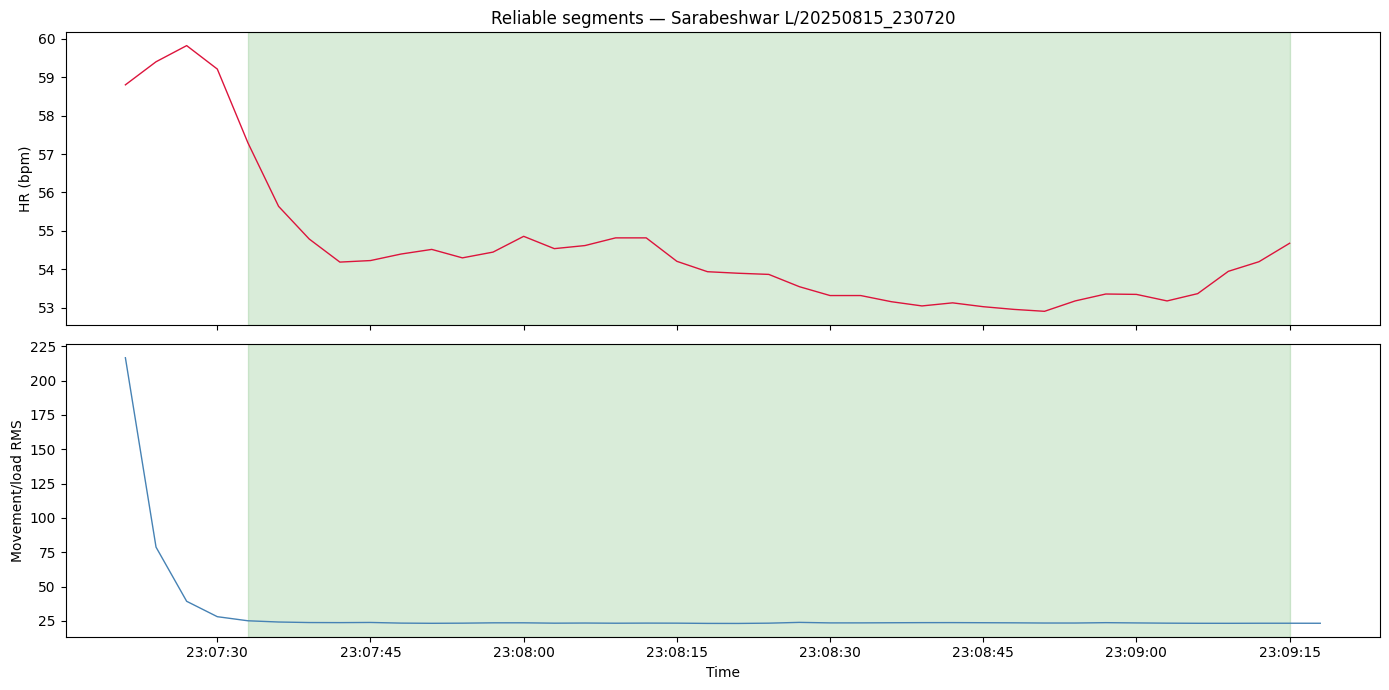

1 reliable segments found in this session, covering 105s of 117s total


In [ ]:
EXAMPLE_SESSION = SESSION_DIRS[0]   # change index to look at a different session

df = load_session(EXAMPLE_SESSION)
df_flagged = compute_reliability(df, CFG)
df_final, seg_df = extract_segments(df_flagged, CFG)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df_final['timestamp'], df_final['hr'], color='crimson', lw=1)
axes[0].set_ylabel('HR (bpm)')
axes[0].set_title(f'Reliable segments — {os.path.relpath(EXAMPLE_SESSION, DATA_ROOT)}')

axes[1].plot(df_final['timestamp'], df_final['rms'], color='steelblue', lw=1)
axes[1].set_ylabel('Movement/load RMS')
axes[1].set_xlabel('Time')

for _, seg in seg_df.iterrows():
    for ax in axes:
        ax.axvspan(seg['start'], seg['end'], color='green', alpha=0.15)

plt.tight_layout()
plt.show()

print(f"{len(seg_df)} reliable segments found in this session, "
      f"covering {seg_df['duration_s'].sum():.0f}s of {(df_final['timestamp'].iloc[-1]-df_final['timestamp'].iloc[0]).total_seconds():.0f}s total")


## 6 — Download the reliable-only dataset

In [ ]:
shutil.make_archive("reliable_dataset", 'zip', OUT_ROOT)
files.download("reliable_dataset.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>